In [1]:
import pandas as pd
import numpy as np

In [2]:
dbd = pd.read_csv('data_kasus_demam_berdarah_tahun_2016_2023.csv')
kemiskinan = pd.read_csv('persentase_penduduk_miskin_menurut_kabupaten_Kota_2016_2023.csv')

In [3]:
dbd.head()
kemiskinan.head()

,kabupaten,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Cilacap,14.12,13.94,11.25,10.73,11.46,11.67,11.02,10.99,10.68,9.41
1,Banyumas,17.23,17.05,13.50,12.53,13.26,13.66,12.84,12.53,11.95,11.15
2,Purbalingga,18.98,18.80,15.62,15.03,15.90,16.24,15.30,14.99,14.18,12.55
3,Banjarnegara,17.46,17.21,15.46,14.76,15.64,16.23,15.20,14.90,14.71,13.28
4,Kebumen,19.86,19.60,17.47,16.82,17.59,17.83,16.41,16.34,15.71,13.58


In [4]:
dbd.shape
kemiskinan.shape

(35, 11)

In [5]:
dbd.isnull().sum()
kemiskinan.isnull().sum()

,0
kabupaten,0
2016,0
2017,0
2018,0
2019,0
2020,0
2021,0
2022,0
2023,0
2024,0


In [6]:
# 2. Standarisasi DBD: "Kab.Cilacap" -> "Kabupaten Cilacap" (sedangkan "Kota " dibiarkan utuh)
dbd['kabupaten'] = dbd['kabupaten'].apply(lambda x: str(x).replace("Kab.", "Kabupaten ").strip())

# 3. Standarisasi Kemiskinan: Tambahkan "Kabupaten " pada wilayah yang bukan Kota
def fix_kemiskinan(x):
    x = str(x).strip()
    if not x.startswith("Kota "):
        return "Kabupaten " + x
    return x

kemiskinan['kabupaten'] = kemiskinan['kabupaten'].apply(fix_kemiskinan)

# 4. Validasi hasil akhir
print("Total Unik DBD :", dbd['kabupaten'].nunique())
print("Total Unik Kemiskinan :", kemiskinan['kabupaten'].nunique())

Total Unik DBD : 35
Total Unik Kemiskinan : 35


In [7]:
tahun = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

dbd_long = []

for _, row in dbd.iterrows():

    for t in tahun:

        dbd_long.append({
            'kabupaten': row['kabupaten'],
            'tahun': t,
            'kasus_dbd': row[f'{t}_sakit'],
            'meninggal_dbd': row[f'{t}_meninggal']
        })

dbd_long = pd.DataFrame(dbd_long)

dbd_long.head(15)

,kabupaten,tahun,kasus_dbd,meninggal_dbd
0,Kabupaten Cilacap,2016,654,9
1,Kabupaten Cilacap,2017,428,6
2,Kabupaten Cilacap,2018,136,1
3,Kabupaten Cilacap,2019,476,9
4,Kabupaten Cilacap,2020,501,5
5,Kabupaten Cilacap,2021,501,5
6,Kabupaten Cilacap,2022,902,19
7,Kabupaten Cilacap,2023,104,5
8,Kabupaten Cilacap,2024,104,11
9,Kabupaten Cilacap,2025,4,0


In [8]:
miskin_long = []

for _, row in kemiskinan.iterrows():

    for t in tahun:

        miskin_long.append({
            'kabupaten': row['kabupaten'],
            'tahun': t,
            'kemiskinan': row[str(t)]
        })

miskin_long = pd.DataFrame(miskin_long)

miskin_long.head(15)

,kabupaten,tahun,kemiskinan
0,Kabupaten Cilacap,2016,14.12
1,Kabupaten Cilacap,2017,13.94
2,Kabupaten Cilacap,2018,11.25
3,Kabupaten Cilacap,2019,10.73
4,Kabupaten Cilacap,2020,11.46
5,Kabupaten Cilacap,2021,11.67
6,Kabupaten Cilacap,2022,11.02
7,Kabupaten Cilacap,2023,10.99
8,Kabupaten Cilacap,2024,10.68
9,Kabupaten Cilacap,2025,9.41


In [9]:
merged = pd.merge(
    dbd_long,
    miskin_long,
    on=['kabupaten','tahun'],
    how='inner'
)

merged.head()

,kabupaten,tahun,kasus_dbd,meninggal_dbd,kemiskinan
0,Kabupaten Cilacap,2016,654,9,14.12
1,Kabupaten Cilacap,2017,428,6,13.94
2,Kabupaten Cilacap,2018,136,1,11.25
3,Kabupaten Cilacap,2019,476,9,10.73
4,Kabupaten Cilacap,2020,501,5,11.46


In [10]:
merged.shape

(350, 5)

In [11]:
# Mencari nilai tengah (median)
median= merged['kasus_dbd'].median()

# Membuat target klasifikasi (1 = Rawan/Tinggi, 0 = Aman/Rendah)
merged['status_rawan_dbd'] = np.where(merged['kasus_dbd'] > median, 1, 0)

# Cek distribusi kelas
print(merged['status_rawan_dbd'].value_counts())

status_rawan_dbd
1    175
0    175
Name: count, dtype: int64


Rata-rata Nilai per Klaster:
   klaster  kemiskinan   kasus_dbd
0        0   15.152660  131.659574
1        1    9.980000  366.301205
2        2   12.550000  675.407407
3        3    8.439726   98.527397
------------------------------


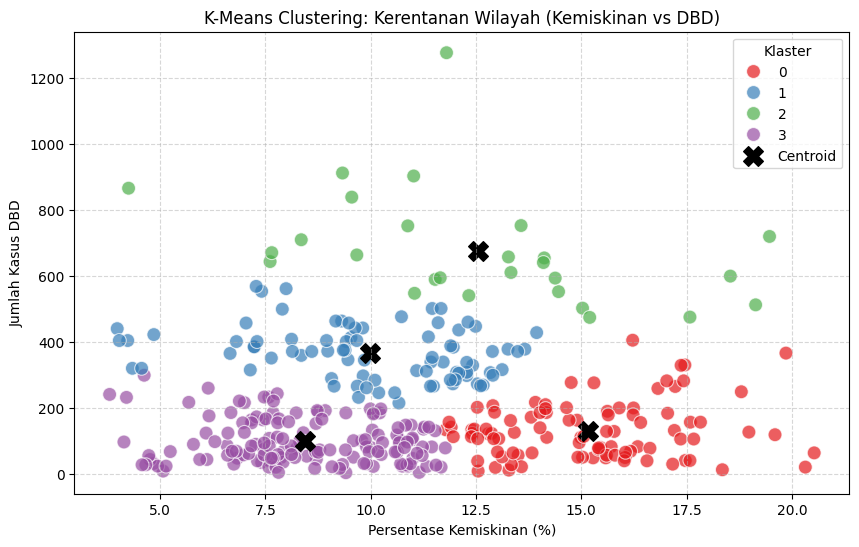

Evaluasi Model K-Means Clustering
Silhouette Score (4 Klaster) : 0.423


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Menentukan fitur yang akan diklasterisasi
X_cluster = merged[['kemiskinan', 'kasus_dbd']]

# 2. Standarisasi Data (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Menerapkan K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
merged['klaster'] = kmeans.fit_predict(X_scaled)

# 4. Analisis Karakteristik Setiap Klaster
cluster_summary = merged.groupby('klaster')[['kemiskinan', 'kasus_dbd']].mean().reset_index()
print("Rata-rata Nilai per Klaster:")
print(cluster_summary)
print("-" * 30)

# 5. Visualisasi Hasil Clustering (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged,
    x='kemiskinan',
    y='kasus_dbd',
    hue='klaster',
    palette='Set1',
    s=100,
    alpha=0.7
)

# Menambahkan titik pusat klaster (Centroids) ke dalam plot
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroid')

plt.title('K-Means Clustering: Kerentanan Wilayah (Kemiskinan vs DBD)')
plt.xlabel('Persentase Kemiskinan (%)')
plt.ylabel('Jumlah Kasus DBD')
plt.legend(title='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#6. Menghitung hasil silhouette score
sil_score = silhouette_score(X_scaled, merged['klaster'])
print(f"Evaluasi Model K-Means Clustering")
print(f"Silhouette Score (4 Klaster) : {sil_score:.3f}")

In [13]:
# 7. Export Data Bersih beserta Label Klasternya ke format JSON untuk Web/Leaflet
merged.to_json('data_jateng_clustered.json', orient='records')
print("Proses Clustering Selesai! Data berhasil disimpan sebagai 'data_jateng_clustered.json'")

Proses Clustering Selesai! Data berhasil disimpan sebagai 'data_jateng_clustered.json'
